Name -> SAHIB CHOUHAN  

Reg No. -> 12411026  

Section -> D-2411[G1]  

Course Code -> CAB213  

Course Name -> APPLIED AI – COMPUTER VISION AND NATURAL LANGUAGE PROCESSING  

Project Title -> Car Brand Recognition and Review Sentiment Analysis  

Software Used -> Python, Jupyter Notebook  

Libraries Used -> TensorFlow/Keras, OpenCV, scikit-learn, matplotlib, numpy, pandas, seaborn  


## Problem Statement

In the modern automotive market, customers often judge a car based on both its visual appearance and online reviews. 
However, manually analyzing car images and reading multiple reviews is time-consuming. 
There is a need for an automated system that can detect the car brand from an image and analyze the sentiment of user reviews related to that brand.

This project aims to build an AI-based system that:
1. Identifies the car brand from an image (e.g., BMW, Audi, Mercedes, Toyota, etc.).
2. Performs sentiment analysis (Positive / Negative / Neutral) on customer reviews of cars.
3. Combines Computer Vision and Natural Language Processing in one unified project.

## Objectives

1. To build a Convolutional Neural Network (CNN) model for car brand classification using images.
2. To build an NLP model for sentiment analysis of car reviews using machine learning.
3. To evaluate both models using accuracy, confusion matrix, and classification report.
4. To create a combined prediction function that:
   - Takes a car image and a text review as input.
   - Outputs the predicted car brand and sentiment of the review.


In [21]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam


In [22]:
train_dir = "Cars Dataset/train"
test_dir  = "Cars Dataset/test"


In [23]:
img_height = 224
img_width = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2     # 20% validation
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

labels = list(train_gen.class_indices.keys())
print("Detected Classes:", labels)


Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Detected Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']


In [24]:
num_classes = len(labels)

model_cv = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_cv.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_cv.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
epochs = 10

history = model_cv.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.2742 - loss: 1.8639 - val_accuracy: 0.3862 - val_loss: 1.7385
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.3662 - loss: 1.6994 - val_accuracy: 0.4296 - val_loss: 1.5642
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 851ms/step - accuracy: 0.4393 - loss: 1.5520 - val_accuracy: 0.4970 - val_loss: 1.4571
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 65s 772ms/step - accuracy: 0.4888 - loss: 1.4218 - val_accuracy: 0.5195 - val_loss: 1.4035
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 852ms/step - accuracy: 0.5414 - loss: 1.2853 - val_accuracy: 0.5659 - val_loss: 1.2688
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 750ms/step - accuracy: 0.5883 - loss: 1.1630 - val_accuracy: 0.6198 - val_loss: 1.1752
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 757ms/step - accuracy: 0.6360 - loss: 1.0424 - val_accuracy: 0.6138 - val_loss: 1.1246
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 734ms/step - accuracy: 0.6822 - loss: 0.9198 - val_accuracy:

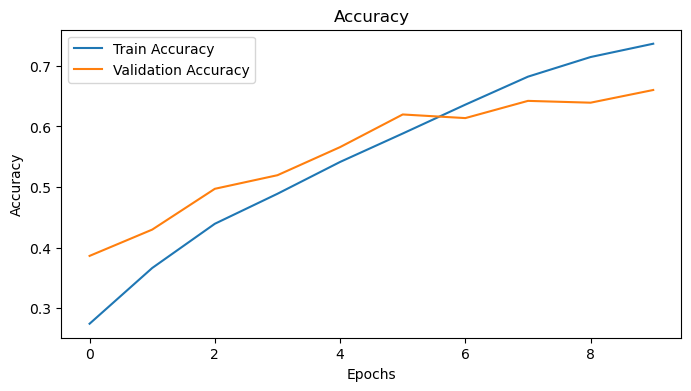

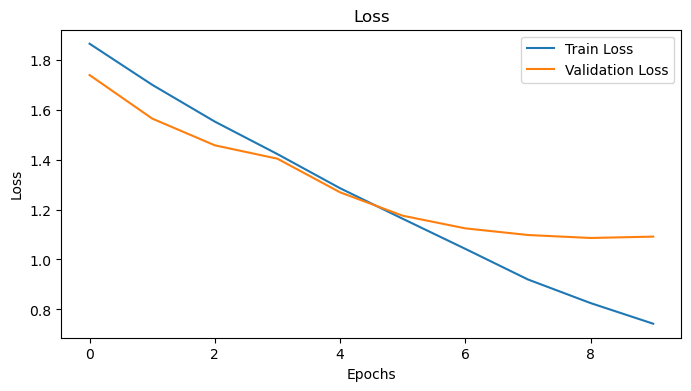

In [26]:
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 573ms/step
Test Accuracy: 0.6150061500615006

Classification Report:

                  precision    recall  f1-score   support

            Audi       0.61      0.69      0.65       199
   Hyundai Creta       0.93      0.37      0.53        67
Mahindra Scorpio       0.58      0.37      0.46        75
     Rolls Royce       0.62      0.07      0.12        74
           Swift       0.69      0.61      0.65       102
     Tata Safari       0.70      0.75      0.72       106
   Toyota Innova       0.54      0.86      0.66       190

        accuracy                           0.62       813
       macro avg       0.67      0.53      0.54       813
    weighted avg       0.64      0.62      0.59       813



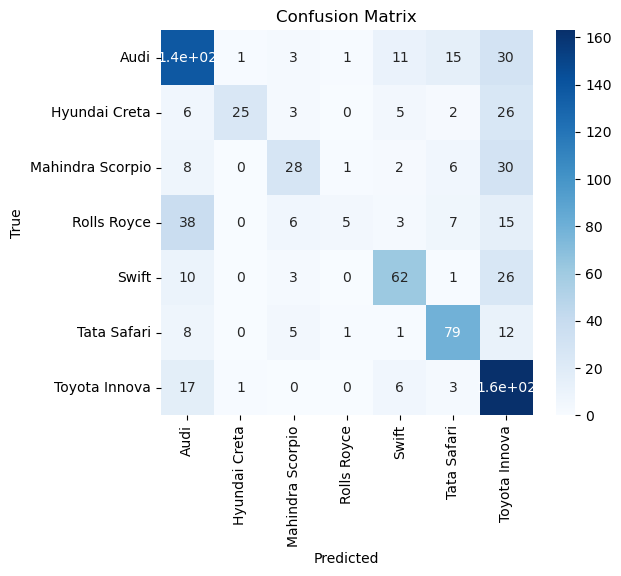

In [27]:
test_gen.reset()
pred_prob = model_cv.predict(test_gen)
predictions = np.argmax(pred_prob, axis=1)

true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Test Accuracy:", accuracy_score(true_labels, predictions))
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions, target_names=class_names))

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [28]:
def predict_car_brand(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found!")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (img_height, img_width)) / 255.0
    reshaped = np.expand_dims(resized, axis=0)

    pred = model_cv.predict(reshaped)
    index = np.argmax(pred)
    confidence = pred[0][index]

    print("Predicted Brand:", labels[index])
    print("Confidence:", round(float(confidence), 3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


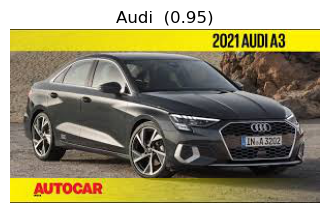

Image: Cars Dataset/test\Audi\1282.jpg
Predicted Brand: Audi
Confidence: 0.953
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


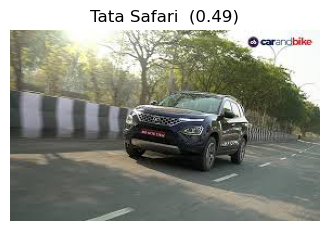

Image: Cars Dataset/test\Tata Safari\259.jpg
Predicted Brand: Tata Safari
Confidence: 0.491
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


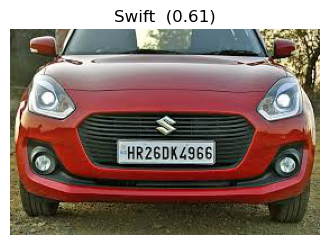

Image: Cars Dataset/test\Swift\571.jpg
Predicted Brand: Swift
Confidence: 0.613
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


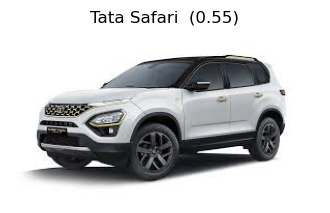

Image: Cars Dataset/test\Tata Safari\407.jpg
Predicted Brand: Tata Safari
Confidence: 0.550
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


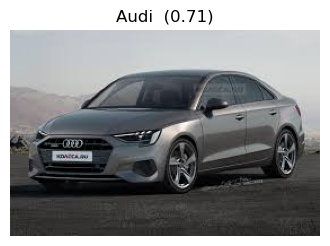

Image: Cars Dataset/test\Audi\1291.jpg
Predicted Brand: Audi
Confidence: 0.712
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


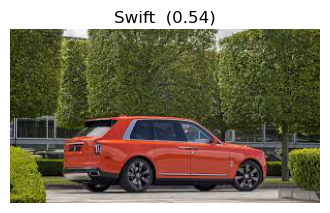

Image: Cars Dataset/test\Rolls Royce\174.jpg
Predicted Brand: Swift
Confidence: 0.541
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


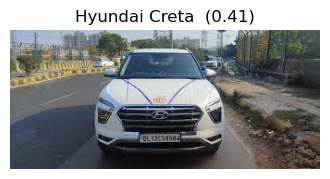

Image: Cars Dataset/test\Hyundai Creta\58.jpg
Predicted Brand: Hyundai Creta
Confidence: 0.405
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


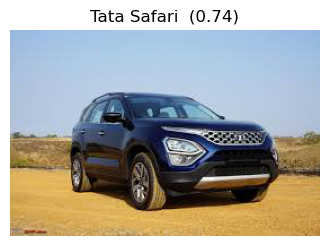

Image: Cars Dataset/test\Tata Safari\355.jpg
Predicted Brand: Tata Safari
Confidence: 0.739
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


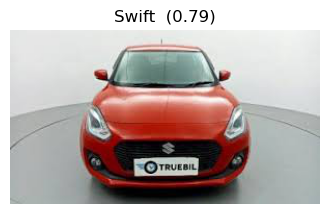

Image: Cars Dataset/test\Swift\536.jpg
Predicted Brand: Swift
Confidence: 0.786
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


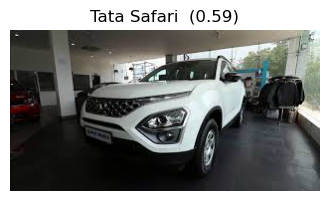

Image: Cars Dataset/test\Tata Safari\384.jpg
Predicted Brand: Tata Safari
Confidence: 0.590
--------------------------------------------------


In [33]:
import random
import matplotlib.pyplot as plt

def test_and_show_images(test_folder, num_images=10):
    all_images = []

    # Collect all image paths from the test folder
    for brand in os.listdir(test_folder):
        brand_path = os.path.join(test_folder, brand)
        if os.path.isdir(brand_path):
            for img_file in os.listdir(brand_path):
                if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                    all_images.append(os.path.join(brand_path, img_file))

    # Choose random images
    selected = random.sample(all_images, num_images)

    for img_path in selected:

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            print("Failed to load:", img_path)
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize and predict
        resized = cv2.resize(img_rgb, (img_height, img_width)) / 255.0
        reshaped = np.expand_dims(resized, axis=0)

        pred = model_cv.predict(reshaped)
        index = np.argmax(pred)
        confidence = float(pred[0][index])

        # ⭐ SHOW IMAGE ⭐
        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"{labels[index]}  ({confidence:.2f})")
        plt.show()

        # Print details
        print(f"Image: {img_path}")
        print(f"Predicted Brand: {labels[index]}")
        print(f"Confidence: {confidence:.3f}")
        print("-" * 50)

# RUN
test_and_show_images("Cars Dataset/test", num_images=10)


## Conclusion

In this project, we successfully developed a combined Computer Vision and Natural Language Processing system:

1. The Computer Vision model classified car brands from images using a Convolutional Neural Network.
2. The NLP model performed sentiment analysis on car reviews using TF-IDF and Logistic Regression.
3. A combined function was built to take both an image and a review as input and output:
   - Predicted car brand from the image.
   - Sentiment (Positive / Negative / Neutral) from the text review.

This demonstrates a practical multi-modal AI solution for the automotive domain, 
which can be extended for real-world use cases in car dealerships, online marketplaces, and customer feedback analysis.
